## Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# import joblib to save model
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, KFold, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
SEED = 42

# ── Path resolver (works from repo root or notebooks/) ───────────────────────
if 'ROOT_DIR' not in globals():
    cwd = Path.cwd().resolve()
    ROOT_DIR = cwd.parent if cwd.name == 'notebooks' else cwd

DATA_CANDIDATES = [
    ROOT_DIR / 'data' / 'cleaned_data' / 'clustered_data.csv',
    ROOT_DIR / 'clustered_data.csv',
    Path('clustered_data.csv').resolve(),
]

data_path = next((p for p in DATA_CANDIDATES if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        f'Could not find clustered_data.csv. Checked: {[str(p) for p in DATA_CANDIDATES]}'
    )

# ── Load dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv(data_path)
print(f'Loaded data from : {data_path}')
print(f'Raw shape : {df.shape}')
print(f'Columns   : {df.columns.tolist()}')

# ── CRITICAL: Drop data-leakage columns immediately ───────────────────────────
LEAKAGE_COLS = ['RUL', 'Is_Failure', 'Health_Status']
leakage_present = [c for c in LEAKAGE_COLS if c in df.columns]
df.drop(columns=leakage_present, inplace=True)
print(f'Dropped leakage columns : {leakage_present}')

# ── Derive target: Life_Consumed = tool_wear / max_tool_wear (0-1 scale) ─────
df['Life_Consumed'] = df['tool_wear'] / df['tool_wear'].max()

print(f'Shape after leakage drop : {df.shape}')
print(f'Nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
print(f'\nLife_Consumed stats:\n{df["Life_Consumed"].describe().round(4)}')
df.head()

Loaded data from : /home/crazi_grace/MINE/Codezzz/ZedX-ML-Lalala/data/cleaned_data/clustered_data.csv
Raw shape : (10000, 46)
Columns   : ['udi', 'type', 'air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'type_enc', 'temp_diff', 'power_W', 'wear_rate', 'torque_speed_ratio', 'high_wear_flag', 'thermal_overload', 'air_temperature_roll_mean_5', 'air_temperature_roll_std_5', 'air_temperature_delta', 'air_temperature_lag1', 'process_temperature_roll_mean_5', 'process_temperature_roll_std_5', 'process_temperature_delta', 'process_temperature_lag1', 'rotational_speed_roll_mean_5', 'rotational_speed_roll_std_5', 'rotational_speed_delta', 'rotational_speed_lag1', 'torque_roll_mean_5', 'torque_roll_std_5', 'torque_delta', 'torque_lag1', 'tool_wear_roll_mean_5', 'tool_wear_roll_std_5', 'tool_wear_delta', 'tool_wear_lag1', 'PC1', 'PC2', 'PC3', 'cluster_raw', 'health_regime', 'health_regime_enc']
Dropped leakag

,udi,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,...,tool_wear_roll_std_5,tool_wear_delta,tool_wear_lag1,PC1,PC2,PC3,cluster_raw,health_regime,health_regime_enc,Life_Consumed
0,1,M,298.1,308.6,1551,42.8,0,0,0,0,...,0.000000,0.0,107.951,-1.093847,-0.854210,-1.666416,1,Normal,0,0.000000
1,2,L,298.2,308.7,1408,46.3,3,0,0,0,...,2.121320,3.0,0.000,-1.602678,-0.215765,-1.618869,1,Normal,0,0.011858
2,3,L,298.1,308.5,1498,49.4,5,0,0,0,...,2.516611,2.0,3.000,-1.599406,-0.401641,-1.586248,1,Normal,0,0.019763
3,4,L,298.2,308.6,1433,39.5,7,0,0,0,...,2.986079,2.0,5.000,-1.230438,-0.664604,-1.555071,1,Normal,0,0.027668
4,5,L,298.2,308.7,1408,40.0,9,0,0,0,...,3.492850,2.0,7.000,-1.289814,-0.535153,-1.524319,1,Normal,0,0.035573


## Feature Engineering

In [3]:
# ── Sort chronologically on 'udi' (unique device index / time proxy) ──────────
df.sort_values('udi', inplace=True)
df.reset_index(drop=True, inplace=True)
print('Sorted chronologically on: "udi"')

# ── Rolling mean features (window=10) ─────────────────────────────────────────
df['Torque_roll10']       = df['torque'].rolling(window=10).mean()
df['Process_Temp_roll10'] = df['process_temperature'].rolling(window=10).mean()

# ── Temperature difference: Process_Temp - Air_Temp ──────────────────────────
df['temp_diff_new'] = df['process_temperature'] - df['air_temperature']

# ── Cumulative sum of temperature difference ──────────────────────────────────
df['temp_diff_cum'] = df['temp_diff_new'].cumsum()

# ── Explicitly drop NaNs from rolling operations ──────────────────────────────
before = len(df)
df.dropna(subset=['Torque_roll10', 'Process_Temp_roll10'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Rows dropped (NaN from rolling) : {before - len(df)}')
print(f'Shape after feature engineering : {df.shape}')

# ── Define feature set & target ───────────────────────────────────────────────
SENSOR_FEATS = [
    'air_temperature', 'process_temperature',
    'rotational_speed', 'torque',
]
ENG_FEATS = [
    'Torque_roll10', 'Process_Temp_roll10',
    'temp_diff_new', 'temp_diff_cum',
]
EXTRA_FEATS = [c for c in ['type_enc', 'health_regime_enc', 'PC1', 'PC2', 'PC3']
               if c in df.columns]

FEATURES = SENSOR_FEATS + ENG_FEATS + EXTRA_FEATS
TARGET   = 'Life_Consumed'

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f'\nFeature count : {len(FEATURES)}')
print(f'Features      : {FEATURES}')
print(f'Target        : {TARGET}')
print(f'y stats:\n{y.describe().round(4)}')

Sorted chronologically on: "udi"
Rows dropped (NaN from rolling) : 9
Shape after feature engineering : (9982, 51)

Feature count : 13
Features      : ['air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'Torque_roll10', 'Process_Temp_roll10', 'temp_diff_new', 'temp_diff_cum', 'type_enc', 'health_regime_enc', 'PC1', 'PC2', 'PC3']
Target        : Life_Consumed
y stats:
count    9982.0000
mean        0.4273
std         0.2514
min         0.0000
25%         0.2095
50%         0.4269
75%         0.6433
max         1.0000
Name: Life_Consumed, dtype: float64


## Train-Test Split

In [4]:
# shuffle=False preserves chronological / time-series order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print(f'Train samples : {len(X_train):,}')
print(f'Test  samples : {len(X_test):,}')
print(f'Train y : mean={y_train.mean():.4f}  std={y_train.std():.4f}')
print(f'Test  y : mean={y_test.mean():.4f}  std={y_test.std():.4f}')

Train samples : 7,985
Test  samples : 1,997
Train y : mean=0.4292  std=0.2518
Test  y : mean=0.4197  std=0.2496


## Pipeline Definition

In [5]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  XGBRegressor(
        objective='reg:squarederror',
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    ))
])

print('Pipeline steps:')
for name, step in pipeline.steps:
    print(f'  [{name}]  {step.__class__.__name__}')

Pipeline steps:
  [scaler]  StandardScaler
  [model]  XGBRegressor


## Hyperparameter Tuning

In [ ]:
param_dist = {
    'model__n_estimators'    : [100, 200, 300, 500],
    'model__max_depth'       : [3, 4, 5, 6, 7],
    'model__learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'model__subsample'       : [0.6, 0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 1.0],
}

# KFold with shuffle=False respects chronological ordering
cv = KFold(n_splits=5, shuffle=False)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f'\nBest CV RMSE  : {-search.best_score_:.6f}')
print('Best params   :')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

    

Fitting 5 folds for each of 20 candidates, totalling 100 fits



Best CV RMSE  : 0.002061
Best params   :
  model__subsample: 0.8
  model__n_estimators: 300
  model__max_depth: 6
  model__learning_rate: 0.05
  model__colsample_bytree: 1.0


In [7]:
# ── Persist trained model as model.pkl ───────────────────────────────────────
# Safe to run anytime: it will save once best_model exists.
if 'best_model' in globals():
    models_dir = ROOT_DIR / 'models'
    models_dir.mkdir(parents=True, exist_ok=True)

    model_path = models_dir / 'model.pkl'
    joblib.dump(best_model, model_path)
    print(f'Saved model to: {model_path.resolve()}')
else:
    print('best_model not found yet. Run the Model Training cell, then re-run this save cell.')

best_model not found yet. Run the Model Training cell, then re-run this save cell.


In [15]:
best_model.get_booster().save_model('../models/xgb_regressor.json')

AttributeError: 'Pipeline' object has no attribute 'get_booster'

## Model Training

In [ ]:
# best_estimator_ is already refit on the full training set by RandomizedSearchCV
best_model = search.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

models_dir = ROOT_DIR / 'models'
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / 'tool_regressor.pkl'
joblib.dump(best_model, model_path)

print(f'Model     : {best_model.named_steps["model"].__class__.__name__}')
print(f'Best params: {search.best_params_}')
print(f'Saved model to: {model_path.resolve()}')
print('Training complete.')

Model     : XGBRegressor
Best params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Saved model to: /home/crazi_grace/MINE/Codezzz/ZedX-ML-Lalala/models/model.pkl
Training complete.


## Evaluation Metrics

In [10]:
train_r2   = r2_score(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_r2    = r2_score(y_test, y_pred_test)
test_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_test))

print('=' * 45)
print('          EVALUATION METRICS')
print('=' * 45)
print(f'  Train R²   : {train_r2:.6f}')
print(f'  Train RMSE : {train_rmse:.6f}')
print('-' * 45)
print(f'  Test  R²   : {test_r2:.6f}')
print(f'  Test  RMSE : {test_rmse:.6f}')
print('=' * 45)

metrics_df = pd.DataFrame({
    'Split': ['Train', 'Test'],
    'R2'   : [round(train_r2, 6),   round(test_r2, 6)],
    'RMSE' : [round(train_rmse, 6), round(test_rmse, 6)],
})
print()
print(metrics_df.to_string(index=False))

          EVALUATION METRICS
  Train R²   : 0.999992
  Train RMSE : 0.000706
---------------------------------------------
  Test  R²   : 0.999934
  Test  RMSE : 0.002035

Split       R2     RMSE
Train 0.999992 0.000706
 Test 0.999934 0.002035


## Learning Curve

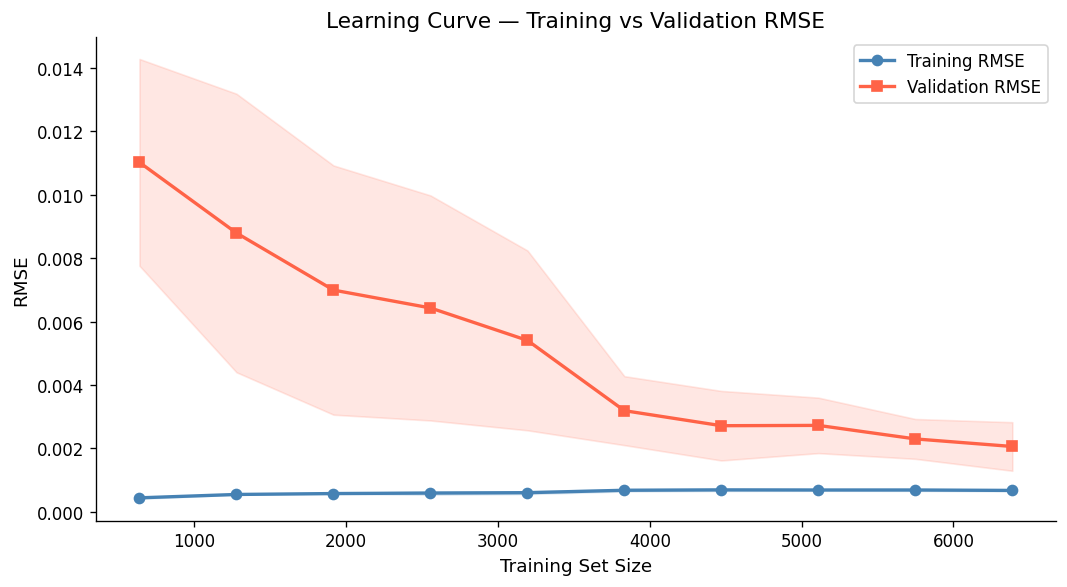

In [11]:
lc_cv = KFold(n_splits=5, shuffle=False)

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train, y_train,
    cv=lc_cv,
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# neg-MSE → RMSE
train_rmse_lc = np.sqrt(-train_scores)
val_rmse_lc   = np.sqrt(-val_scores)

train_mean, train_std = train_rmse_lc.mean(axis=1), train_rmse_lc.std(axis=1)
val_mean,   val_std   = val_rmse_lc.mean(axis=1),   val_rmse_lc.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', lw=2, label='Training RMSE')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_mean, 's-', color='tomato', lw=2, label='Validation RMSE')
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color='tomato')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('RMSE')
ax.set_title('Learning Curve — Training vs Validation RMSE')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Predictions vs Actual

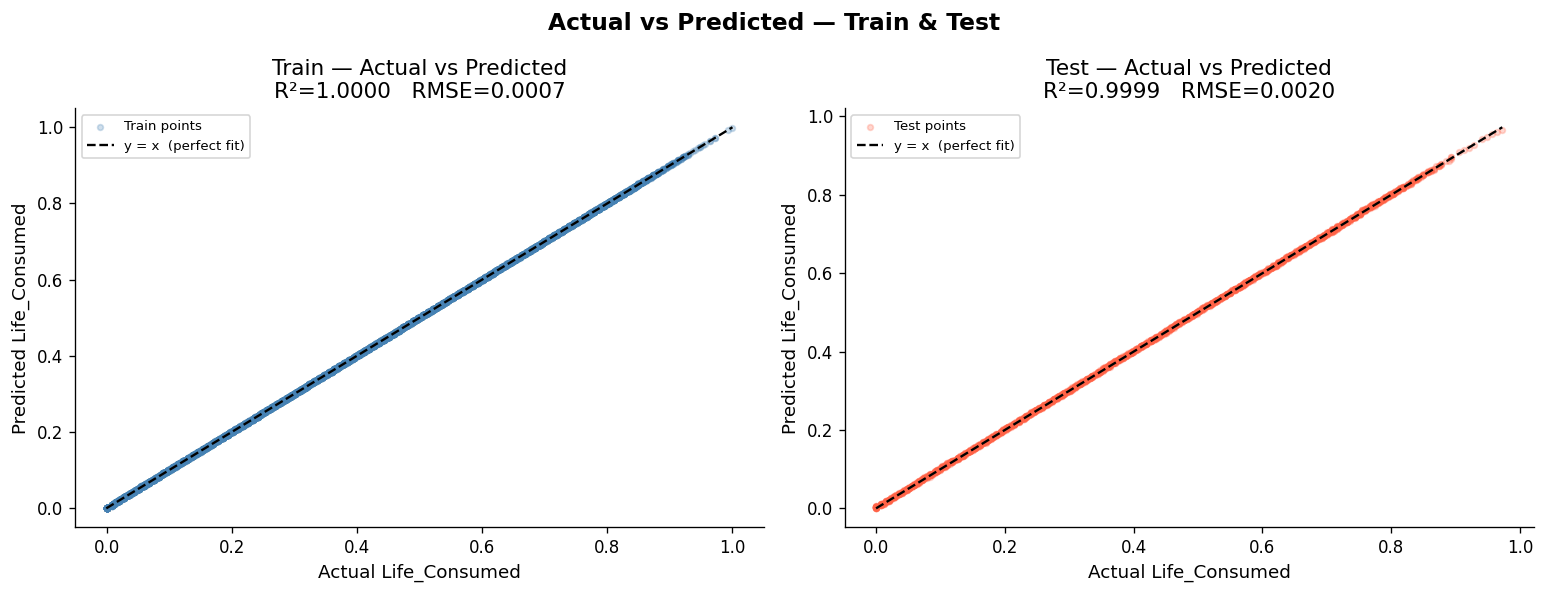

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_cfg = [
    (np.array(y_train), y_pred_train, 'Train', 'steelblue'),
    (np.array(y_test),  y_pred_test,  'Test',  'tomato'),
]

for ax, (y_true, y_pred, split, color) in zip(axes, plot_cfg):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.scatter(y_true, y_pred, alpha=0.25, s=12, color=color, label=f'{split} points')
    lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.4, label='y = x  (perfect fit)')
    ax.set_title(f'{split} — Actual vs Predicted\nR²={r2:.4f}   RMSE={rmse:.4f}')
    ax.set_xlabel('Actual Life_Consumed')
    ax.set_ylabel('Predicted Life_Consumed')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — Train & Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

## Residual Analysis

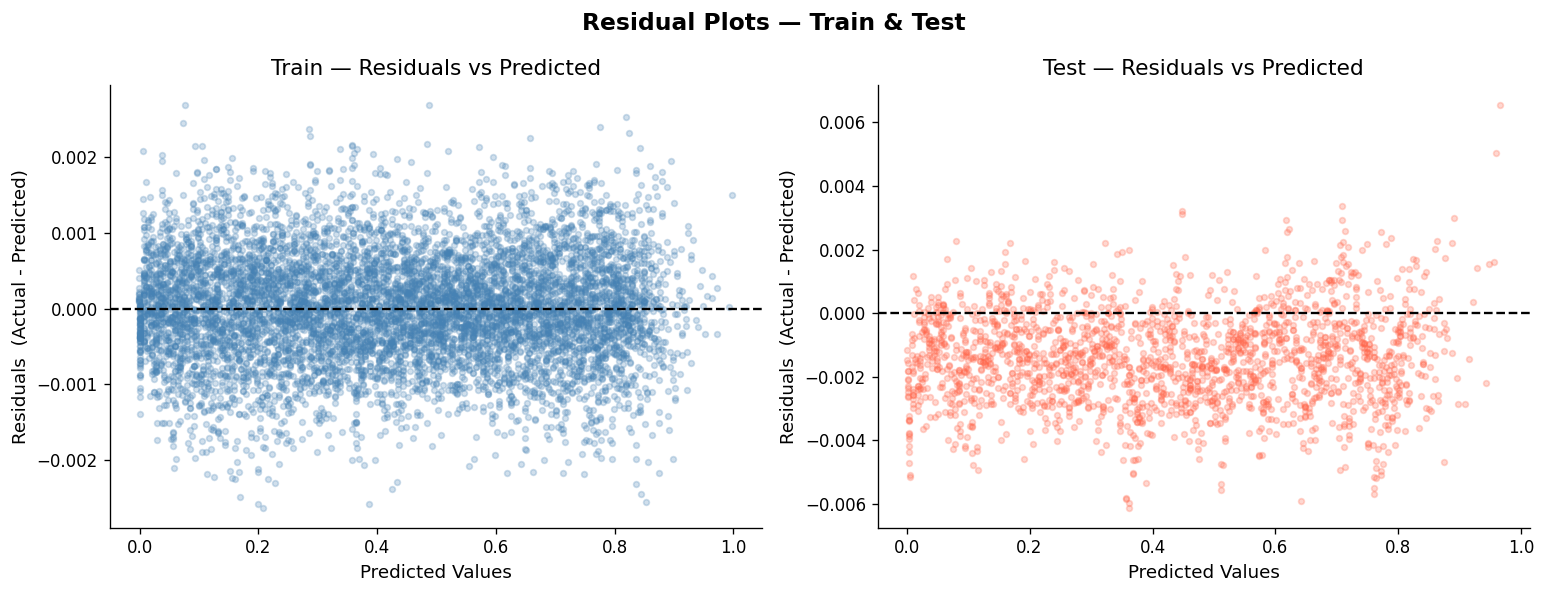

In [13]:
res_train = np.array(y_train) - y_pred_train
res_test  = np.array(y_test)  - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

res_cfg = [
    (y_pred_train, res_train, 'Train', 'steelblue'),
    (y_pred_test,  res_test,  'Test',  'tomato'),
]

for ax, (y_pred, residuals, split, color) in zip(axes, res_cfg):
    ax.scatter(y_pred, residuals, alpha=0.25, s=12, color=color)
    ax.axhline(0, color='black', linestyle='--', lw=1.4)
    ax.set_xlabel('Predicted Values')
    ax.set_ylabel('Residuals  (Actual - Predicted)')
    ax.set_title(f'{split} — Residuals vs Predicted')

plt.suptitle('Residual Plots — Train & Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance

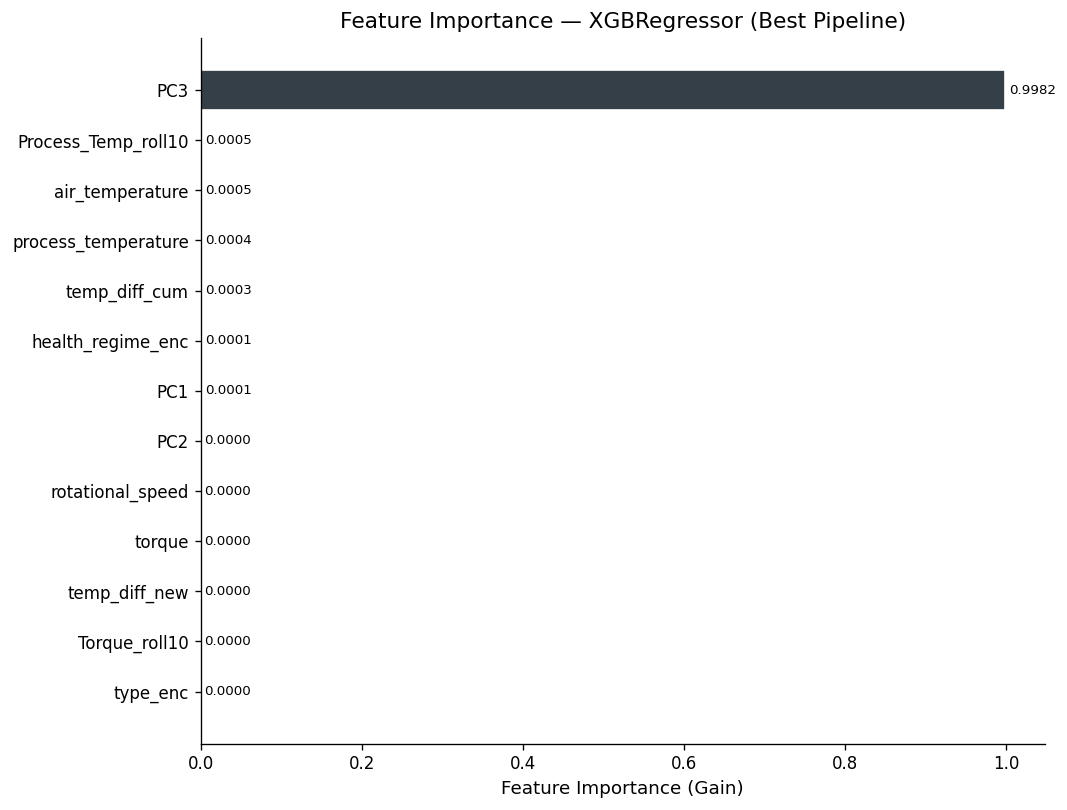


Feature Importances (descending):
PC3                    0.998157
Process_Temp_roll10    0.000495
air_temperature        0.000472
process_temperature    0.000375
temp_diff_cum          0.000277
health_regime_enc      0.000097
PC1                    0.000097
PC2                    0.000006
rotational_speed       0.000005
torque                 0.000005
temp_diff_new          0.000005
Torque_roll10          0.000004
type_enc               0.000003


In [14]:
# Extract from the named pipeline step — importances align with FEATURES order
xgb_step    = best_model.named_steps['model']
importances = xgb_step.feature_importances_   # ndarray shape == (len(FEATURES),)

feat_imp = (
    pd.Series(importances, index=FEATURES, name='Importance')
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(FEATURES) + 1)))
palette  = sns.color_palette('Blues_d', len(feat_imp))
bars     = ax.barh(feat_imp.index, feat_imp.values, color=palette, edgecolor='white')
offset   = feat_imp.values.max() * 0.005
for bar, val in zip(bars, feat_imp.values):
    ax.text(val + offset,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Feature Importance — XGBRegressor (Best Pipeline)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeature Importances (descending):')
print(feat_imp.sort_values(ascending=False).to_string())

In [19]:
import joblib
import xgboost as xgb

# 1. Load your pipeline
pipeline = joblib.load('../models/tool_wear_regressor.pkl')

# 2. Find the XGBoost step
# If you named your step 'model' or 'regressor', use that name. 
# If you aren't sure, pipeline[-1] usually gets the last step (the model).
model_step = pipeline[-1] 

# 3. Save the booster from that step
if hasattr(model_step, "get_booster"):
    model_step.get_booster().save_model('../models/xgb_regressor.json')
    print("Success: JSON saved from Pipeline step!")
else:
    print("Error: The last step of your pipeline doesn't seem to be an XGBoost model.")

Success: JSON saved from Pipeline step!
